# Neural network classifier

___

## Data onboarding and preprocessing

### Load data

In [1]:
import os 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.typing import NDArray

np.random.seed(42)

dir_path = "training_data"

data = []
for label in range(10): 
    for file_path in [os.path.join(dir_path, f) for f in os.listdir(dir_path) if ".csv" in f and f"stroke_{label}" in f]: 
        data.append((label, pd.read_csv(file_path, header=None)))

features, labels = [X for _, X in data], [y for y, _ in data]

### Project to 2D

In [3]:
from sklearn.decomposition import PCA
from typing import Optional

# Define function to project 3D data to 2D using PCA
def project_to_2d(data_3d: pd.DataFrame|NDArray, 
                  weights: Optional[NDArray]=None, inverse_weights: Optional[NDArray]=None,
                  keep_dims: bool=False) -> list[pd.DataFrame]:
    
    # Convert data to numpy array if needed
    if isinstance(data_3d, pd.DataFrame): data_3d = data_3d.to_numpy()

    # Calculate the variances in each dimension and sort dimensions by variance
    order = np.argsort(-np.var(data_3d, axis=0))
    inverse = np.empty_like(order)
    inverse[order] = np.arange(len(order))
    
    # By default, return only 2D data (keep_dims=True also returns the 3rd PCA component)
    n_components = 2 if not keep_dims else data_3d.shape[1]
    data_3d = data_3d[:, inverse]
    # Apply default weights if none provided (= no weights)
    #if weights is None: weights = np.ones(3)
    #if inverse_weights is None: inverse_weights = np.ones(3)

    # Apply weights and project data to 2D using PCA
    # data_3d = data_3d * weights
    data_projected = PCA(n_components=data_3d.shape[1]).fit_transform(data_3d) 

    # Reorder the projected dimensions by original variance order
    #data_projected = data_projected[:, order]

    # Apply inverse weights and return projected data
    # data_projected = data_projected_weighted * inverse_weights
    return data_projected[:, :n_components]

In [4]:
# Define variables for PCA usage
use_PCA, use_weights_PCA = True, False

if use_PCA and use_weights_PCA: 
    
    # Define weights for PCA
    weights = np.array([1.0, 2.0, 0.5])
    inverse_weights = 1 / np.array([2.0, 1.0, 0.5])

    # Project the features to 2D using PCA with weights
    projected_features = [project_to_2d(X, weights, inverse_weights) for X in features]

elif use_PCA: # Use PCA without weights
    
    # Project the features to 2D using PCA without weights
    projected_features = [project_to_2d(X) for X in features]

else: 

    # Reorder the dimensions for image processing
    new_order = [1, 0, 2] 
    projected_features = [X[:, new_order] for X in features]

### Convert data to images

In [5]:
from typing import List

# Define a function to convert 2D/3D coordinates to images
def convert_to_image(data_projected: NDArray, size: tuple) -> NDArray: 

    # Initialize empty image
    width, height = size 
    image = np.zeros((height, width))

    # Center and scale the data to range [-1, 1]
    min_values, max_values = np.min(data_projected, axis=0), np.max(data_projected, axis=0)
    data_projected = data_projected - (min_values + max_values) / 2
    data_projected = data_projected / np.max(np.abs(data_projected)) # Scale to range [-1, 1]

    # Extract x and y data and scale to [0, N-1] (pixel coordinates)
    x_data, y_data = data_projected[:, 1], data_projected[:, 0] # Note: swap x and y for image coordinates
    x_data = x_data * ((width-1) / 2) + ((width-1) / 2)
    y_data = y_data * ((height-1) / 2) + ((height-1) / 2)

    # Compute floor and ceil values
    x_floor, x_ceil = np.floor(x_data).astype(int), np.ceil(x_data).astype(int)
    y_floor, y_ceil = np.floor(y_data).astype(int), np.ceil(y_data).astype(int)

    # Convert x, y data to pixels in an image
    image[y_floor, x_floor] += (1 - y_data % 1) * (1 - x_data % 1)
    image[y_ceil, x_ceil] += (y_data % 1) * (x_data % 1)
    image[y_floor, x_ceil] += (x_data % 1) * (1 - y_data % 1)
    image[y_ceil, x_floor] += (1 - x_data % 1) * (y_data % 1)

    # Clip the pixel values to range [0, 1]
    image = np.clip(image, 0, 1)  

    # Flip the image (so that it is not upside down)
    image = np.flip(image, 0)
    
    return image

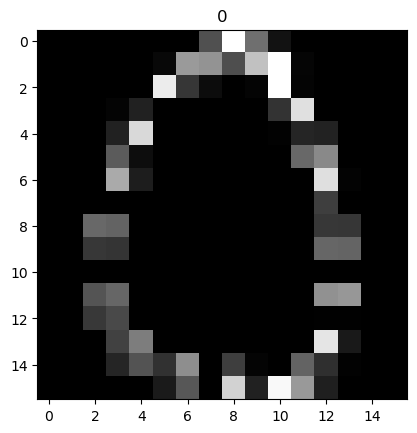

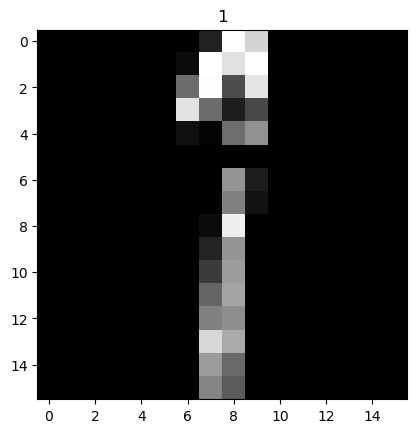

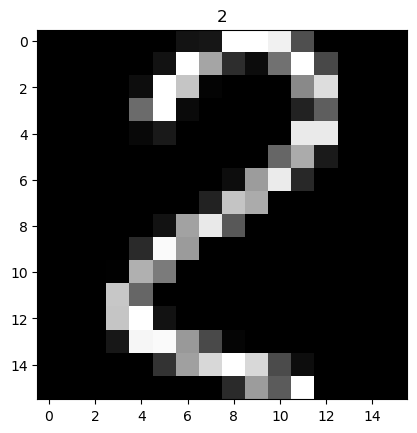

In [6]:
# Choose image size
image_size = (16, 16)

# Convert projected features to images
images = [convert_to_image(p, image_size) for p in projected_features]

# Show some images
for label, image in zip(labels[:300:100], images[:300:100]): 
    plt.figure()
    plt.imshow(image, cmap='Grays_r')
    plt.title(label)

### Stack images and labels to arrays

In [7]:
X = np.stack(images)
y = np.array(labels)
print(X.shape, y.shape)

(1000, 16, 16) (1000,)


___

## Training the model 

### Split data to training and test sets

In [8]:
from neural_network import *
from sklearn.model_selection import train_test_split

# Flatten the samples
X_flat = np.array([x.flatten() for x in X])

# One-hot encode y
y_encoded = one_hot_encode(y, np.arange(10))

# Split the data to training/validation and test sets
X_train, X_test, y_train, y_test = train_test_split(X_flat, y_encoded, test_size=0.15, stratify=y, random_state=42)

### Define model

In [9]:
from numpy.random import uniform

model = NeuralNetworkClassifier(
    Dense(uniform(-0.1, 0.1, size=(X_flat.shape[1], 256)), np.zeros(256), ReLU),
    Dense(uniform(-0.1, 0.1, size=(256, 128)), np.zeros(128), ReLU), 
    Dense(uniform(-0.1, 0.1, size=(128, 10)), np.zeros(10), Softmax)
)

### Train the model 

  1%|▏         | 149/10000 [00:03<04:03, 40.44it/s]


Model accuracy (training set): 98 %
Model accuracy (test set): 93 %


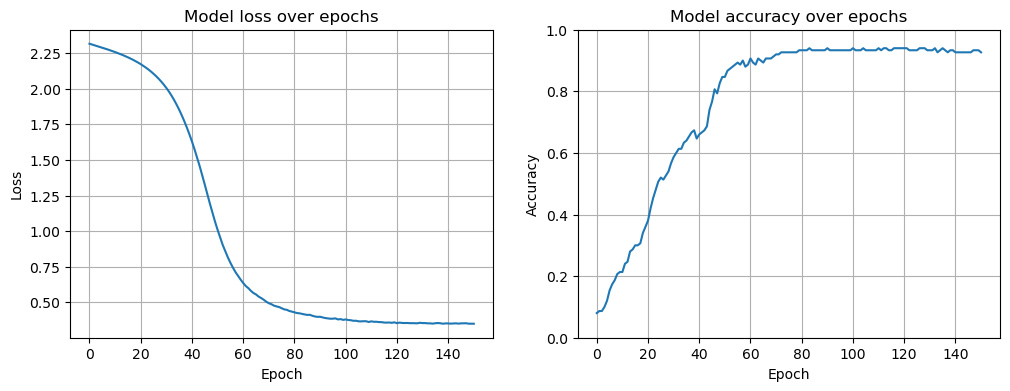

In [10]:
import matplotlib.pyplot as plt

# Training parameters
epochs, batch_size, learning_rate, tol, min_loss = 10000, 64, 0.1, 1e-4, 1e-8
criterion = CategoricalCrossEntropySoftmax()

# Train the model  
loss_history, accuracy_history = train(model, X_train, y_train, X_val=X_test, y_val=y_test,
    criterion=criterion, max_iter=epochs, batch_size=batch_size, learning_rate=learning_rate, 
    tol=tol, min_loss=min_loss, verbose=True
)

# Visualize training and validation loss
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(loss_history)
plt.title("Model loss over epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()

# Visualize validation accuracy
ax = plt.subplot(1, 2, 2)
ax.set_ylim([0, 1])
plt.grid()
plt.plot(accuracy_history)
plt.title("Model accuracy over epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

# Measure accuracy
y_pred = model.forward(X_train)
print(f"Model accuracy (training set): {accuracy_score(np.argmax(y_train, axis=1), np.argmax(y_pred, axis=1))*100:.0f} %")

# Measure accuracy
y_pred = model.forward(X_test)
print(f"Model accuracy (test set): {accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_pred, axis=1))*100:.0f} %")

Further training

  0%|          | 10/10000 [00:00<07:14, 22.98it/s]


Model accuracy (training set): 98 %
Model accuracy (test set): 93 %


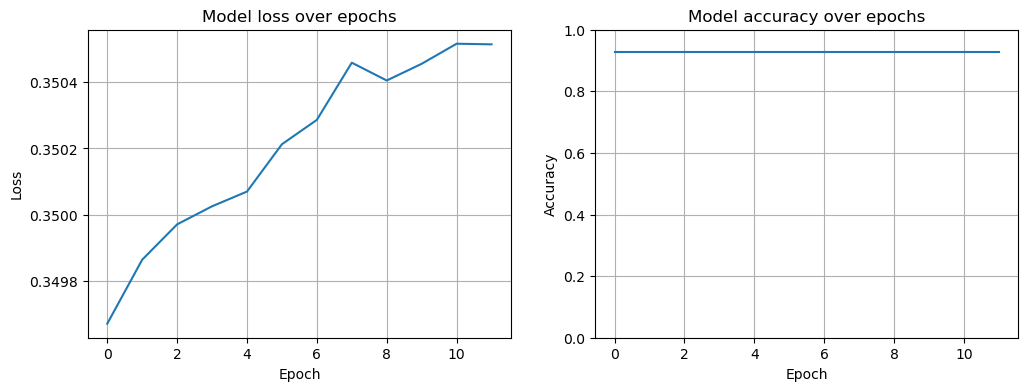

In [11]:
# Training parameters
epochs, batch_size, learning_rate, tol, min_loss = 10000, 64, 0.01, 1e-5, 1e-8
criterion = CategoricalCrossEntropySoftmax()

# Train the model  
loss_history, accuracy_history = train(model, X_train, y_train, X_val=X_test, y_val=y_test,
    criterion=criterion, max_iter=epochs, batch_size=batch_size, learning_rate=learning_rate, 
    tol=tol, min_loss=min_loss, verbose=True
)

# Visualize training and validation loss
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(loss_history)
plt.title("Model loss over epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()

# Visualize validation accuracy
ax = plt.subplot(1, 2, 2)
ax.set_ylim([0, 1])
plt.grid()
plt.plot(accuracy_history)
plt.title("Model accuracy over epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

# Measure accuracy
y_pred = model.forward(X_train)
print(f"Model accuracy (training set): {accuracy_score(np.argmax(y_train, axis=1), np.argmax(y_pred, axis=1))*100:.0f} %")

# Measure accuracy
y_pred = model.forward(X_test)
print(f"Model accuracy (test set): {accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_pred, axis=1))*100:.0f} %")

___

## Combining the preprocessing pipeline and NN classifier to a single function

In [12]:
from typing import List, Union

Sample = Union[NDArray, pd.DataFrame]

def classify(samples: List[Sample], model: NeuralNetworkClassifier) -> NDArray: 

    # Preprocess the samples
    samples_projected = project_to_2d(samples)
    
    N = 16 # Image width/height
    samples_images = []

    for coordinates in samples_projected: 

        # Scale the coordinates
        coordinates = coordinates - (np.min(coordinates, axis=0) + np.max(coordinates, axis=0)) / 2 # Center the sample to 0
        coordinates = coordinates / np.max(np.abs(coordinates)) # Scale to range [-1, 1]
        coordinates = coordinates * ((N-1) / 2) + ((N-1) / 2) # Scale to range [0, N-1]

        # Extract coordinates
        x, y, z = coordinates[:, 1], coordinates[:, 0], 1
        x_floor, x_ceil = np.floor(x).astype(int), np.ceil(x).astype(int)
        y_floor, y_ceil = np.floor(y).astype(int), np.ceil(y).astype(int)

        # Convert x, y data to pixels in an image
        image = np.zeros((N, N))
        image[y_floor, x_floor] += z * ((1 - y % 1) * (1 - x % 1))
        image[y_ceil, x_ceil] += z * ((y % 1) * (x % 1))
        image[y_floor, x_ceil] += z * ((x % 1) * (1 - y % 1))
        image[y_ceil, x_floor] += z * ((1 - x % 1) * (y % 1))

        # Clip the pixel values to range [0, 1]
        image = np.clip(image, 0, 1)
        
        # Flip the image (so that it is not upside down) and add it to list
        image = np.flip(image, 0)

        # Add image to list
        samples_images.append(image)

    # Prepare the data for classification
    X_flat = np.array([x.flatten() for x in samples_images])

    # Classify the samples
    y_pred = model.forward(X_flat)

    return np.argmax(y_pred, axis=1)

